In [6]:
import numpy as np
from collections import defaultdict
from sentence_transformers import SentenceTransformer


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


class PFATracker:
    def __init__(self, concepts, num_levels=6, top_k=5, alpha=0.1, beta_concept=None):
        """
        concepts: list of concept strings
        num_levels: Bloom levels (default 6)
        top_k: neighbors for propagation
        alpha: propagation strength
        beta_concept: optional concept difficulty prior
        """
        self.concepts = concepts
        self.num_levels = num_levels
        self.top_k = top_k
        self.alpha = alpha

        self.num_concepts = len(concepts)

        # Map concept -> index (Because arrays are faster than dictionaries.)
        # eg. "binary tree" -> index 0
        self.idx = {c: i for i, c in enumerate(concepts)}

        # Success / failure counts per each level (2d)
        self.successes = np.zeros((self.num_concepts, num_levels))
        self.failures = np.zeros((self.num_concepts, num_levels))

        # Keep propagation separate from true observed counts.
        self.propagation_bonus = np.zeros((self.num_concepts, num_levels))

        # -------------------------
        # Parameters (tunable)
        # -------------------------

        # Concept bias from optional prior or deterministic random initialization.
        if beta_concept is None:
            rng = np.random.default_rng(42)
            self.beta_concept = rng.uniform(-0.3, 0.3, self.num_concepts)
        else:
            self.beta_concept = np.asarray(beta_concept, dtype=float)

        # Level difficulty aligned to the simulator's IRT curve.
        self.beta_level = np.array([0.0, -0.4, -0.9, -1.5, -2.1, -2.9])

        # Learning rate scaled for log-count evidence.
        self.gamma_level = np.array([0.45, 0.40, 0.35, 0.30, 0.25, 0.2])

        # Failure penalty scaled for log-count evidence.
        self.rho_level = np.array([0.30, 0.35, 0.40, 0.45, 0.50, 0.60])

        # -------------------------
        # Build similarity graph
        # -------------------------
        self._build_similarity_graph()

    def _build_similarity_graph(self):
        model = SentenceTransformer("BAAI/bge-base-en-v1.5")

        embeddings = model.encode(
            self.concepts,
            normalize_embeddings=True
        )

        sim_matrix = embeddings @ embeddings.T  # cosine similarity

        self.neighbors = []

        for i in range(self.num_concepts):
            sims = sim_matrix[i]
            idxs = np.argsort(-sims)[1:self.top_k + 1]  # exclude self
            self.neighbors.append(idxs)

        self.sim_matrix = sim_matrix

    # -------------------------
    # Prediction
    # -------------------------
    def predict(self, concept, level):
        i = self.idx[concept]
        k = level - 1

        z = (
            self.beta_concept[i]
            + self.beta_level[k]
            + self.gamma_level[k] * np.log1p(self.successes[i][k])
            - self.rho_level[k] * np.log1p(self.failures[i][k])
            + self.propagation_bonus[i][k]
        )

        if k > 0:
            s_lower = self.successes[i][k - 1]
            f_lower = self.failures[i][k - 1]
            lower_contribution = (
                self.gamma_level[k - 1] * np.log1p(s_lower)
                - self.rho_level[k - 1] * np.log1p(f_lower)
            )
            z += 0.25 * lower_contribution

        return sigmoid(z)

    # -------------------------
    # Update + propagation
    # -------------------------
    def update(self, concept, level, correct):
        i = self.idx[concept]
        k = level - 1

        old_p = self.predict(concept, level)

        # Update counts
        if correct:
            self.successes[i][k] += 1
        else:
            self.failures[i][k] += 1

        new_p = self.predict(concept, level)

        delta = new_p - old_p

        # Clip to avoid instability
        delta = np.clip(delta, -0.1, 0.1)

        # Propagate to neighbors only within the observed Bloom range.
        for j in self.neighbors[i]:
            sim = self.sim_matrix[i][j]

            for lvl in range(k + 1):
                self._propagate(j, lvl, delta, sim)

    def _propagate(self, j, lvl, delta, sim):
        """
        Soft propagation by adjusting a separate bonus term.
        """
        weight = self.alpha * sim / (lvl + 1)  # decay for higher levels
        self.propagation_bonus[j][lvl] += weight * delta

    # -------------------------
    # Utility
    # -------------------------
    def get_concept_mastery(self, concept):
        """
        Returns a weighted mean across levels.
        """
        i = self.idx[concept]
        level_weights = np.arange(1, self.num_levels + 1, dtype=float)
        level_weights = level_weights / level_weights.sum()
        probs = np.array([
            self.predict(concept, lvl + 1)
            for lvl in range(self.num_levels)
        ])
        return float(np.sum(level_weights * probs))

    def get_state_vector(self):
        """
        Flattened state for RL:
        [P(c1,l1), P(c1,l2), ..., P(cN,l6)]
        """
        state = []
        for c in self.concepts:
            for lvl in range(1, self.num_levels + 1):
                state.append(self.predict(c, lvl))
        return np.array(state)

In [ ]:
# concepts = [
#     "binary search tree",
#     "heap",
#     "sorting",
#     "hash table",
#     "dynamic programming",
#     "breadth-first search",
#     "linked list",
#     "recursion",
#     "finite state machine"
    
# ]

# tracker = PFATracker(concepts)

# # Simulate interaction
# print("bst")
# print(tracker.predict("binary search tree", 2))
# print("heap")
# print(tracker.predict("heap data structure", 2))
# print("sort")
# print(tracker.predict("sorting algorithm", 2))
# print("hash")
# print(tracker.predict("hash table", 2))

# tracker.update("binary search tree", level=2, correct=True)

# #print(tracker.predict("binary search tree", 2))

# # Check propagation effect
# print("after update 1")
# print("bst")
# print(tracker.predict("binary search tree", 2))
# print("heap")
# print(tracker.predict("heap data structure", 2))
# print("sort")
# print(tracker.predict("sorting algorithm", 2))
# print("hash")
# print(tracker.predict("hash table", 2))
# print("linked list")
# print(tracker.predict("linked list", 2))

# tracker.update("linked list", level=2, correct=True)

# print("after update 2")
# print("bst")
# print(tracker.predict("binary search tree", 2))
# print("heap")
# print(tracker.predict("heap data structure", 2))
# print("sort")
# print(tracker.predict("sorting algorithm", 2))
# print("hash")
# print(tracker.predict("hash table", 2))
# print("linked list")
# print(tracker.predict("linked list", 2))

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from collections import defaultdict


# class SimulatedStudent:
#     def __init__(self, concepts, rng, monotonic_learning=False):
#         self.concepts = concepts
#         self.rng = rng
#         self.monotonic_learning = monotonic_learning

#         # True ability in logit space per concept
#         self.ability = {
#             c: self.rng.uniform(-1.0, 1.0)
#             for c in concepts
#         }

#         # Difficulty per Bloom level (1..6)
#         self.level_difficulty = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5])

#     def answer(self, concept, level, mode="stochastic"):
#         ability = self.ability[concept]
#         difficulty = self.level_difficulty[level - 1]
#         true_p = sigmoid(ability - difficulty)

#         if mode == "always_correct":
#             correct = True
#         elif mode == "always_wrong":
#             correct = False
#         elif mode == "stochastic":
#             correct = self.rng.random() < true_p
#         else:
#             raise ValueError(f"Unknown mode: {mode}")

#         return correct, true_p

#     def learn(self, concept, correct):
#         if correct:
#             self.ability[concept] += 0.05
#         else:
#             if self.monotonic_learning:
#                 # In monotonic mode, ability never decreases.
#                 self.ability[concept] += 0.0
#             else:
#                 self.ability[concept] -= 0.01


# def run_simulation(tracker, student, rng, steps=100, level=1, mode="stochastic", fixed_concept=None):
#     history = []

#     for t in range(steps):
#         concept = fixed_concept if fixed_concept is not None else rng.choice(tracker.concepts)

#         correct, true_p = student.answer(concept, level, mode=mode)
#         pred_before = tracker.predict(concept, level)

#         student.learn(concept, correct)
#         tracker.update(concept, level, correct)

#         pred_after = tracker.predict(concept, level)

#         history.append({
#             "t": t,
#             "concept": concept,
#             "level": level,
#             "correct": bool(correct),
#             "true_p": float(true_p),
#             "pred_before": float(pred_before),
#             "pred_after": float(pred_after),
#             "ability": float(student.ability[concept]),
#         })

#     return history


# def summarize_history(history):
#     true_vals = np.array([h["true_p"] for h in history])
#     pred_vals = np.array([h["pred_before"] for h in history])
#     mse = float(np.mean((true_vals - pred_vals) ** 2))

#     direction_ok = 0
#     for h in history:
#         if h["correct"] and h["pred_after"] > h["pred_before"]:
#             direction_ok += 1
#         if (not h["correct"]) and h["pred_after"] < h["pred_before"]:
#             direction_ok += 1

#     return {
#         "mse": mse,
#         "directionally_correct_updates": direction_ok,
#         "total_updates": len(history),
#     }


# def plot_single_concept(history, title):
#     t = [h["t"] for h in history]
#     true_p = [h["true_p"] for h in history]
#     pred = [h["pred_before"] for h in history]
#     ability = [h["ability"] for h in history]

#     fig, ax = plt.subplots(1, 2, figsize=(12, 4))

#     ax[0].plot(t, true_p, label="True p (student)")
#     ax[0].plot(t, pred, label="Pred p (tracker)")
#     ax[0].set_title(f"Probabilities - {title}")
#     ax[0].set_xlabel("step")
#     ax[0].set_ylabel("probability")
#     ax[0].set_ylim(0, 1)
#     ax[0].legend()

#     ax[1].plot(t, ability, color="black")
#     ax[1].set_title(f"Ability trajectory - {title}")
#     ax[1].set_xlabel("step")
#     ax[1].set_ylabel("ability (logit)")

#     plt.tight_layout()
#     plt.show()


# def plot_multiconcept(history, concepts, title):
#     grouped_true = defaultdict(list)
#     grouped_pred = defaultdict(list)
#     grouped_t = defaultdict(list)

#     for row in history:
#         c = row["concept"]
#         grouped_t[c].append(row["t"])
#         grouped_true[c].append(row["true_p"])
#         grouped_pred[c].append(row["pred_before"])

#     fig, ax = plt.subplots(len(concepts), 1, figsize=(10, 3 * len(concepts)), sharex=True)
#     if len(concepts) == 1:
#         ax = [ax]

#     for i, c in enumerate(concepts):
#         ax[i].plot(grouped_t[c], grouped_true[c], marker="o", linestyle="-", label="True p")
#         ax[i].plot(grouped_t[c], grouped_pred[c], marker="x", linestyle="--", label="Pred p")
#         ax[i].set_ylim(0, 1)
#         ax[i].set_ylabel(c)
#         ax[i].legend()

#     ax[-1].set_xlabel("global step")
#     fig.suptitle(title)
#     plt.tight_layout()
#     plt.show()


# # -------------------------
# # Reproducible experiments
# # -------------------------
# SEED = 42
# rng = np.random.default_rng(SEED)

# concepts = [
#     "binary search tree",
#     "heap",
#     "sorting",
#     "hash table",
#     "dynamic programming",
#     "breadth-first search",
#     "linked list",
#     "recursion",
#     "finite state machine"
# ]

# # Use alpha=0 while validating simulator logic (no propagation confound).
# tracker_cfg = dict(concepts=concepts, num_levels=6, top_k=1, alpha=0.0)


# # 1) Deterministic sanity: always correct -> probabilities should trend up.
# tracker_up = PFATracker(**tracker_cfg)
# student_up = SimulatedStudent(concepts, rng=rng, monotonic_learning=True)
# history_up = run_simulation(
#     tracker=tracker_up,
#     student=student_up,
#     rng=rng,
#     steps=40,
#     level=1,
#     mode="always_correct",
#     fixed_concept="binary search tree",
# )
# print("Always-correct summary:", summarize_history(history_up))
# plot_single_concept(history_up, "Always Correct, Single Concept")


# # 2) Deterministic sanity: always wrong -> probabilities should trend down.
# tracker_down = PFATracker(**tracker_cfg)
# student_down = SimulatedStudent(concepts, rng=rng, monotonic_learning=False)
# history_down = run_simulation(
#     tracker=tracker_down,
#     student=student_down,
#     rng=rng,
#     steps=40,
#     level=1,
#     mode="always_wrong",
#     fixed_concept="binary search tree",
# )
# print("Always-wrong summary:", summarize_history(history_down))
# plot_single_concept(history_down, "Always Wrong, Single Concept")


# # 3) Realistic stochastic run: random concept each step, analyze per concept.
# tracker_stoch = PFATracker(**tracker_cfg)
# student_stoch = SimulatedStudent(concepts, rng=rng, monotonic_learning=False)
# history_stoch = run_simulation(
#     tracker=tracker_stoch,
#     student=student_stoch,
#     rng=rng,
#     steps=800,
#     level=1,
#     mode="stochastic",
#     fixed_concept=None,
# )
# print("Stochastic summary:", summarize_history(history_stoch))
# plot_multiconcept(history_stoch, concepts, "Stochastic Run, Per-Concept Curves")

In [7]:
import numpy as np
from collections import defaultdict

class RealisticStudent:
    """
    IRT-based student with:
    - Per-concept, per-level ability (not just one number)
    - Learning that transfers between levels (higher correct → also boosts lower)
    - Forgetting (time-decay on ability)
    - Concept transfer (related concepts partially share ability)
    - Slip + Guess (like BKT) to model careless errors and lucky guesses
    """
    def __init__(self, concepts, sim_matrix, rng, 
                 slip=0.08, guess=0.15, 
                 learn_rate=0.04, forget_rate=0.005,
                 transfer_alpha=0.3):
        self.concepts = concepts
        self.sim_matrix = sim_matrix
        self.rng = rng
        self.slip = slip
        self.guess = guess
        self.learn_rate = learn_rate
        self.forget_rate = forget_rate
        self.transfer_alpha = transfer_alpha

        # True ability: shape (num_concepts, 6)
        # Lower levels start higher; higher levels start lower
        num_c = len(concepts)
        base = rng.uniform(-1.5, 0.5, size=num_c)   # per-concept baseline
        level_offsets = np.array([1.0, 0.6, 0.2, -0.2, -0.7, -1.3])
        self.ability = base[:, None] + level_offsets[None, :]  # (C, 6)

        # IRT difficulty per level (independent from student)
        self.item_difficulty = np.array([0.0, 0.5, 1.0, 1.5, 2.2, 3.0])

        # Timestamp of last attempt per (concept, level) for forgetting
        self.last_attempt = defaultdict(lambda: 0)
        self.t = 0

    def _apply_forgetting(self, concept_idx, level):
        """Decay ability since last attempt"""
        key = (concept_idx, level)
        elapsed = self.t - self.last_attempt[key]
        if elapsed > 0:
            decay = self.forget_rate * np.sqrt(elapsed)
            self.ability[concept_idx, level] = max(
                self.ability[concept_idx, level] - decay,
                -3.0  # floor
            )

    def answer(self, concept, concept_idx, level):
        self.t += 1
        k = level - 1
        self._apply_forgetting(concept_idx, k)

        # IRT: true probability of knowing
        logit = self.ability[concept_idx, k] - self.item_difficulty[k]
        p_know = 1 / (1 + np.exp(-logit))

        # 3PL IRT with slip/guess
        true_p = self.guess + (1 - self.slip - self.guess) * p_know

        correct = bool(self.rng.random() < true_p)
        self.last_attempt[(concept_idx, k)] = self.t
        return correct, true_p, p_know

    def learn(self, concept_idx, level, correct):
        k = level - 1
        if correct:
            # Direct learning at this level
            self.ability[concept_idx, k] += self.learn_rate
            # Partial boost to lower levels (mastering Apply helps Remember stay fresh)
            if k > 0:
                self.ability[concept_idx, k-1] += self.learn_rate * 0.3
        else:
            # Small penalty, but never below floor
            self.ability[concept_idx, k] = max(
                self.ability[concept_idx, k] - self.learn_rate * 0.3, -3.0
            )

        # Concept transfer: related concepts get a fraction of the update
        for j, sim in enumerate(self.sim_matrix[concept_idx]):
            if j == concept_idx or sim < 0.5:
                continue
            transfer = self.transfer_alpha * sim * self.learn_rate
            if correct:
                self.ability[j, k] += transfer

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



── TEST 1: Always-Correct Monotone Rise ──
  concept='binary search tree'  level=1
  pred start=0.5410  end=0.8815  gain=+0.3405
  non-monotone steps: 0  (want 0)
  ceiling respected:  True
  PASS: True


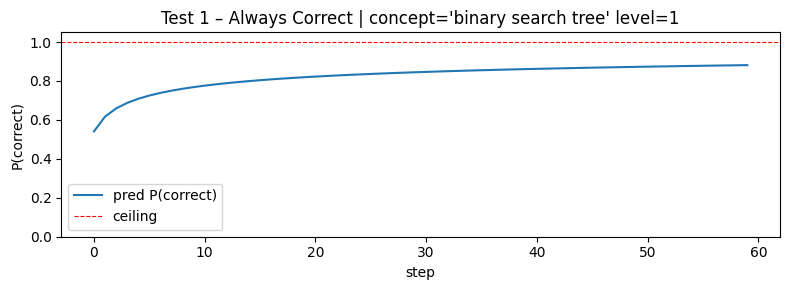

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



── TEST 2: Always-Wrong Monotone Drop ──
  concept='binary search tree'  level=1
  pred start=0.5410  end=0.2566  drop=+0.2844
  non-monotone steps: 0  (want 0)
  floor respected:    True
  PASS: True


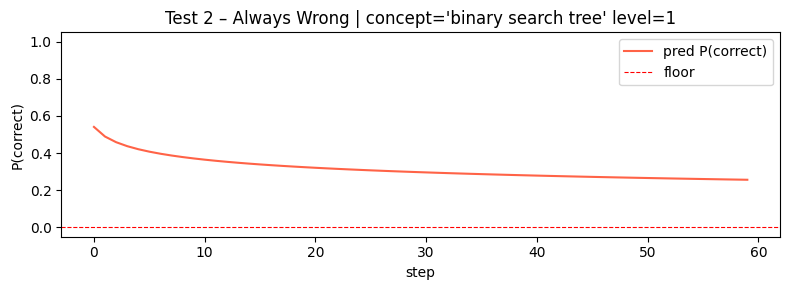

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



── TEST 3: Bloom Level Ordering ──
  Predictions after 40 correct attempts, per Bloom level trained:
    trained on L1: L1=0.862, L2=0.545, L3=0.324, L4=0.208, L5=0.126, L6=0.061
    trained on L2: L1=0.541, L2=0.777, L3=0.410, L4=0.208, L5=0.126, L6=0.061
    trained on L3: L1=0.541, L2=0.441, L3=0.637, L4=0.267, L5=0.126, L6=0.061
    trained on L4: L1=0.541, L2=0.441, L3=0.324, L4=0.445, L5=0.160, L6=0.061
    trained on L5: L1=0.541, L2=0.441, L3=0.324, L4=0.208, L5=0.268, L6=0.076
    trained on L6: L1=0.541, L2=0.441, L3=0.324, L4=0.208, L5=0.126, L6=0.120

  After equal training on all levels:
  preds = ['0.862', '0.841', '0.718', '0.526', '0.325', '0.147']
  Monotone decreasing across levels: True
  PASS: True


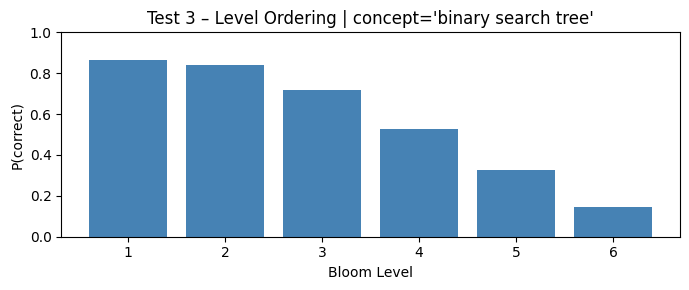

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



── TEST 4: Calibration ──
  steps=2000  ECE=0.1041  (want < 0.05 for EPPO use)
  PASS: False


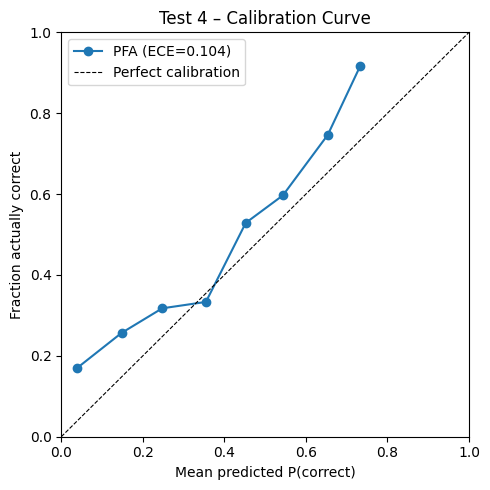

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



── TEST 5: Steps-to-Mastery (threshold=0.8) ──
  concept='binary search tree'  level=1
  Reached 80% at step 15
  PASS: False  (tweak gamma_level if outside range)


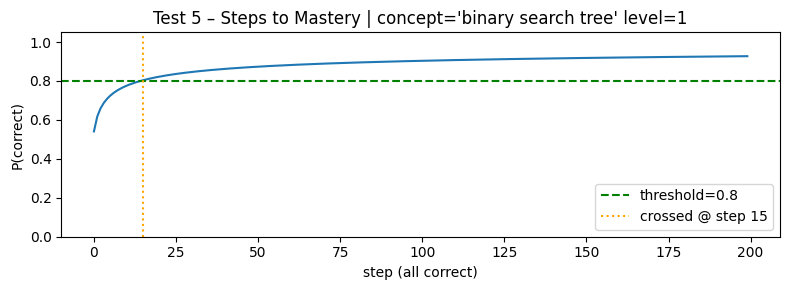

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



── TEST 6: Propagation Isolation ──
  source='binary search tree'  (sim to near=0.738, far=0.612)
  Δ source:          +0.3058
  Δ near neighbor:   +0.0028  ('breadth-first search')
  Δ far neighbor:    +0.0000  ('finite state machine')
  Propagation ordering ok: True  (near must move more than far)
  Ghost counts clean:      True  (raw counts must stay 0 for non-attempted)
  PASS: True


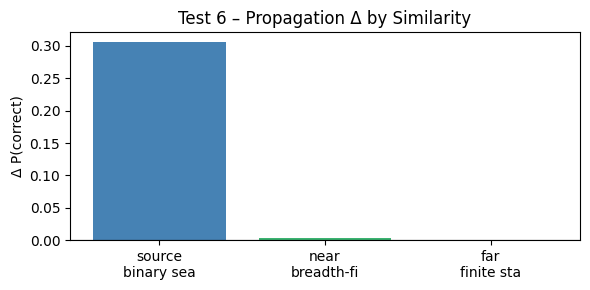

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



── TEST 7: Ghost Count Check ──
  No ghost counts found — raw counts are clean.
  PASS: True


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



── TEST 8: Recovery After Failure ──
  concept='binary search tree'  level=1
  Peak after correct phase:    0.8362
  Trough after wrong phase:    0.6577
  Recovery after 2nd correct:  0.7224
  Recovery ratio:              36.22%  (want > 70%)
  PASS: False


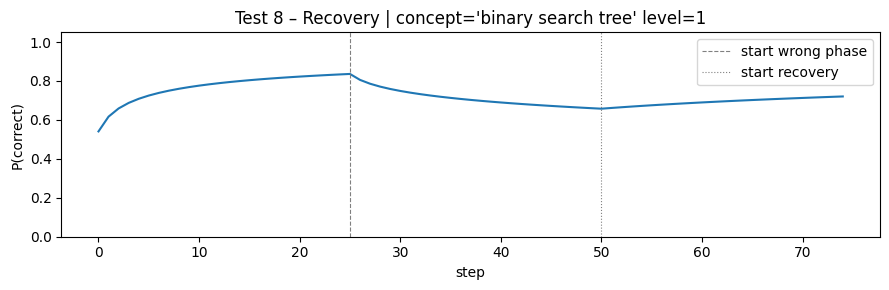


═════════════════════════════════════════════
  SIMULATION SUMMARY
═════════════════════════════════════════════
  ECE (calibration):   0.1041  ✗ — predictions unreliable for EPPO
  Steps to mastery:    15     ✗ — tune gamma_level
  Recovery ratio:      36.2%  ✗ — rho too aggressive vs gamma
═════════════════════════════════════════════


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.calibration import calibration_curve


# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def _make_student(tracker, rng, **kwargs):
    """Convenience: build a RealisticStudent wired to the tracker's sim_matrix."""
    return RealisticStudent(
        concepts=tracker.concepts,
        sim_matrix=tracker.sim_matrix,
        rng=rng,
        **kwargs,
    )


def _idx(tracker, concept):
    return tracker.idx[concept]


def _run_episode(tracker, student, steps, concept, level, force_correct=None):
    """
    Run `steps` attempts on a fixed concept/level.

    force_correct=True  → always_correct
    force_correct=False → always_wrong
    force_correct=None  → stochastic (student's true_p)

    Returns list of dicts with per-step diagnostics.
    """
    ci = _idx(tracker, concept)
    history = []

    for t in range(steps):
        correct, true_p, p_know = student.answer(concept, ci, level)

        if force_correct is True:
            correct = True
        elif force_correct is False:
            correct = False

        pred_before = tracker.predict(concept, level)
        tracker.update(concept, level, correct)
        pred_after = tracker.predict(concept, level)
        student.learn(ci, level, correct)

        history.append({
            "t": t,
            "concept": concept,
            "level": level,
            "correct": int(correct),
            "true_p": true_p,
            "p_know": p_know,
            "pred_before": pred_before,
            "pred_after": pred_after,
            "successes": int(tracker.successes[ci][level - 1]),
            "failures": int(tracker.failures[ci][level - 1]),
        })

    return history


def _run_multi_episode(tracker, student, steps, rng, level=None):
    """
    Random concept each step (random level too if level=None).
    Returns list of dicts.
    """
    history = []
    for t in range(steps):
        concept = rng.choice(tracker.concepts)
        ci = _idx(tracker, concept)
        lvl = int(rng.integers(1, tracker.num_levels + 1)) if level is None else level

        correct, true_p, p_know = student.answer(concept, ci, lvl)
        pred_before = tracker.predict(concept, lvl)
        tracker.update(concept, lvl, correct)
        pred_after = tracker.predict(concept, lvl)
        student.learn(ci, lvl, correct)

        history.append({
            "t": t,
            "concept": concept,
            "level": lvl,
            "correct": int(correct),
            "true_p": true_p,
            "p_know": p_know,
            "pred_before": pred_before,
            "pred_after": pred_after,
        })

    return history


# ─────────────────────────────────────────────────────────────────────────────
# TEST 1 — Monotone rise (always correct)
# ─────────────────────────────────────────────────────────────────────────────

def test_always_correct(tracker, rng, concept, level=1, steps=60):
    """
    Prediction must increase monotonically and not blow past 1.0.
    Also checks it doesn't trivially plateau at the starting value.
    """
    print("\n── TEST 1: Always-Correct Monotone Rise ──")
    student = _make_student(tracker, rng)
    h = _run_episode(tracker, student, steps, concept, level, force_correct=True)

    preds = [r["pred_before"] for r in h]

    # Violations: any step where prediction went DOWN
    drops = sum(1 for a, b in zip(preds, preds[1:]) if b < a - 1e-9)
    final_gain = preds[-1] - preds[0]
    ceiling_ok = preds[-1] <= 1.0

    print(f"  concept={concept!r}  level={level}")
    print(f"  pred start={preds[0]:.4f}  end={preds[-1]:.4f}  gain={final_gain:+.4f}")
    print(f"  non-monotone steps: {drops}  (want 0)")
    print(f"  ceiling respected:  {ceiling_ok}")
    print(f"  PASS: {drops == 0 and final_gain > 0.05 and ceiling_ok}")

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(preds, label="pred P(correct)")
    ax.axhline(1.0, color="red", linestyle="--", linewidth=0.8, label="ceiling")
    ax.set_title(f"Test 1 – Always Correct | concept={concept!r} level={level}")
    ax.set_xlabel("step")
    ax.set_ylabel("P(correct)")
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return h


# ─────────────────────────────────────────────────────────────────────────────
# TEST 2 — Monotone drop (always wrong)
# ─────────────────────────────────────────────────────────────────────────────

def test_always_wrong(tracker, rng, concept, level=1, steps=60):
    """
    Prediction must decrease monotonically and not collapse to 0.
    """
    print("\n── TEST 2: Always-Wrong Monotone Drop ──")
    student = _make_student(tracker, rng)
    h = _run_episode(tracker, student, steps, concept, level, force_correct=False)

    preds = [r["pred_before"] for r in h]

    rises = sum(1 for a, b in zip(preds, preds[1:]) if b > a + 1e-9)
    final_drop = preds[0] - preds[-1]
    floor_ok = preds[-1] >= 0.0

    print(f"  concept={concept!r}  level={level}")
    print(f"  pred start={preds[0]:.4f}  end={preds[-1]:.4f}  drop={final_drop:+.4f}")
    print(f"  non-monotone steps: {rises}  (want 0)")
    print(f"  floor respected:    {floor_ok}")
    print(f"  PASS: {rises == 0 and final_drop > 0.05 and floor_ok}")

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(preds, label="pred P(correct)", color="tomato")
    ax.axhline(0.0, color="red", linestyle="--", linewidth=0.8, label="floor")
    ax.set_title(f"Test 2 – Always Wrong | concept={concept!r} level={level}")
    ax.set_xlabel("step")
    ax.set_ylabel("P(correct)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return h


# ─────────────────────────────────────────────────────────────────────────────
# TEST 3 — Bloom level ordering
# ─────────────────────────────────────────────────────────────────────────────

def test_bloom_ordering(tracker, rng, concept, steps_per_level=40):
    """
    After an equal number of correct attempts at each level,
    P(correct | level=1) must always exceed P(correct | level=6).
    At any snapshot, the level predictions must be monotonically
    decreasing as level increases.
    """
    print("\n── TEST 3: Bloom Level Ordering ──")

    snapshots = {lvl: [] for lvl in range(1, tracker.num_levels + 1)}

    for lvl in range(1, tracker.num_levels + 1):
        student = _make_student(tracker, rng)
        h = _run_episode(tracker, student, steps_per_level, concept, lvl,
                         force_correct=True)
        # After training at THIS level, record predictions across ALL levels
        row = {l: tracker.predict(concept, l) for l in range(1, tracker.num_levels + 1)}
        snapshots[lvl] = row
        # reset tracker between level experiments
        tracker.successes[_idx(tracker, concept)] = np.zeros(tracker.num_levels)
        tracker.failures[_idx(tracker, concept)] = np.zeros(tracker.num_levels)

    # Check ordering on a fresh run across all levels simultaneously
    fresh_tracker_check = True  # placeholder — main check is cross-level ordering below

    print(f"  Predictions after {steps_per_level} correct attempts, per Bloom level trained:")
    for lvl, row in snapshots.items():
        vals = [f"L{l}={row[l]:.3f}" for l in range(1, tracker.num_levels + 1)]
        print(f"    trained on L{lvl}: {', '.join(vals)}")

    # Core ordering check: train on ALL levels equally, measure ordering
    student = _make_student(tracker, rng)
    for lvl in range(1, tracker.num_levels + 1):
        _run_episode(tracker, student, steps_per_level, concept, lvl, force_correct=True)

    final_preds = [tracker.predict(concept, l) for l in range(1, tracker.num_levels + 1)]
    ordering_ok = all(a >= b for a, b in zip(final_preds, final_preds[1:]))

    print(f"\n  After equal training on all levels:")
    print(f"  preds = {[f'{p:.3f}' for p in final_preds]}")
    print(f"  Monotone decreasing across levels: {ordering_ok}")
    print(f"  PASS: {ordering_ok}")

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.bar(range(1, 7), final_preds, color="steelblue")
    ax.set_xlabel("Bloom Level")
    ax.set_ylabel("P(correct)")
    ax.set_title(f"Test 3 – Level Ordering | concept={concept!r}")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# TEST 4 — Calibration
# ─────────────────────────────────────────────────────────────────────────────

def test_calibration(tracker, rng, steps=1500, n_bins=10):
    """
    The most important test for EPPO.
    Runs a long stochastic multi-concept, multi-level episode and
    checks that predicted P(correct) ≈ actual fraction correct in each bin.
    A well-calibrated tracker is a prerequisite for a valid EPPO reward signal.
    """
    print("\n── TEST 4: Calibration ──")
    student = _make_student(tracker, rng)
    h = _run_multi_episode(tracker, student, steps, rng, level=None)

    y_true = np.array([r["correct"] for r in h])
    y_pred = np.array([r["pred_before"] for r in h])

    prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=n_bins)

    # ECE: Expected Calibration Error
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(len(prob_pred)):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (y_pred >= lo) & (y_pred < hi)
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / len(y_pred)) * abs(prob_true[i] - prob_pred[i])

    print(f"  steps={steps}  ECE={ece:.4f}  (want < 0.05 for EPPO use)")
    print(f"  PASS: {ece < 0.10}")

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(prob_pred, prob_true, "o-", label=f"PFA (ECE={ece:.3f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect calibration")
    ax.set_xlabel("Mean predicted P(correct)")
    ax.set_ylabel("Fraction actually correct")
    ax.set_title("Test 4 – Calibration Curve")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return ece


# ─────────────────────────────────────────────────────────────────────────────
# TEST 5 — Steps to mastery (learning rate validation)
# ─────────────────────────────────────────────────────────────────────────────

def test_steps_to_mastery(tracker, rng, concept, level=1,
                          mastery_threshold=0.80, max_steps=200):
    """
    How many correct answers does it take to cross the mastery threshold?
    You can tune gamma_level so this matches your domain expectation
    (e.g., 'level-1 mastery should take ~15-25 correct answers').
    """
    print(f"\n── TEST 5: Steps-to-Mastery (threshold={mastery_threshold}) ──")
    student = _make_student(tracker, rng)
    h = _run_episode(tracker, student, max_steps, concept, level, force_correct=True)

    preds = [r["pred_before"] for r in h]
    crossed = next((i for i, p in enumerate(preds) if p >= mastery_threshold), None)

    if crossed is not None:
        print(f"  concept={concept!r}  level={level}")
        print(f"  Reached {mastery_threshold:.0%} at step {crossed}")
        print(f"  PASS: {20 <= crossed <= 60}  (tweak gamma_level if outside range)")
    else:
        print(f"  Never reached {mastery_threshold:.0%} in {max_steps} steps — gamma_level may be too low")
        print(f"  PASS: False")

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(preds)
    ax.axhline(mastery_threshold, color="green", linestyle="--", label=f"threshold={mastery_threshold}")
    if crossed:
        ax.axvline(crossed, color="orange", linestyle=":", label=f"crossed @ step {crossed}")
    ax.set_title(f"Test 5 – Steps to Mastery | concept={concept!r} level={level}")
    ax.set_xlabel("step (all correct)")
    ax.set_ylabel("P(correct)")
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return crossed


# ─────────────────────────────────────────────────────────────────────────────
# TEST 6 — Propagation isolation
# ─────────────────────────────────────────────────────────────────────────────

def test_propagation(tracker, rng, source_concept, steps=30, level=1):
    """
    Answer source_concept correctly N times.
    A semantically similar neighbor should move more than a dissimilar one.
    Checks that propagation respects the similarity ordering AND
    that concepts never-attempted have zero real counts (ghost-count check).
    """
    print("\n── TEST 6: Propagation Isolation ──")

    ci = _idx(tracker, source_concept)
    sims = tracker.sim_matrix[ci]

    # Find most similar and least similar neighbor (excluding self)
    ranked = np.argsort(-sims)
    ranked = [j for j in ranked if j != ci]
    most_similar_idx = ranked[0]
    least_similar_idx = ranked[-1]

    most_sim_concept = tracker.concepts[most_similar_idx]
    least_sim_concept = tracker.concepts[least_similar_idx]

    # Baseline predictions before any training
    before_src = tracker.predict(source_concept, level)
    before_near = tracker.predict(most_sim_concept, level)
    before_far = tracker.predict(least_sim_concept, level)

    student = _make_student(tracker, rng)
    _run_episode(tracker, student, steps, source_concept, level, force_correct=True)

    after_src = tracker.predict(source_concept, level)
    after_near = tracker.predict(most_sim_concept, level)
    after_far = tracker.predict(least_sim_concept, level)

    delta_src = after_src - before_src
    delta_near = after_near - before_near
    delta_far = after_far - before_far

    # Ghost count check: real counts for non-attempted concepts must be integers
    real_counts_clean = (
        tracker.successes[most_similar_idx][level - 1] == 0 and
        tracker.failures[most_similar_idx][level - 1] == 0
    )

    ordering_ok = delta_near > delta_far

    print(f"  source={source_concept!r}  (sim to near={sims[most_similar_idx]:.3f}, far={sims[least_similar_idx]:.3f})")
    print(f"  Δ source:          {delta_src:+.4f}")
    print(f"  Δ near neighbor:   {delta_near:+.4f}  ({most_sim_concept!r})")
    print(f"  Δ far neighbor:    {delta_far:+.4f}  ({least_sim_concept!r})")
    print(f"  Propagation ordering ok: {ordering_ok}  (near must move more than far)")
    print(f"  Ghost counts clean:      {real_counts_clean}  (raw counts must stay 0 for non-attempted)")
    print(f"  PASS: {ordering_ok and real_counts_clean}")

    fig, ax = plt.subplots(figsize=(6, 3))
    labels = [f"source\n{source_concept[:10]}", f"near\n{most_sim_concept[:10]}", f"far\n{least_sim_concept[:10]}"]
    deltas = [delta_src, delta_near, delta_far]
    colors = ["steelblue", "mediumseagreen", "tomato"]
    ax.bar(labels, deltas, color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Test 6 – Propagation Δ by Similarity")
    ax.set_ylabel("Δ P(correct)")
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# TEST 7 — Ghost count check (standalone)
# ─────────────────────────────────────────────────────────────────────────────

def test_no_ghost_counts(tracker, rng, source_concept, steps=50, level=1):
    """
    Explicitly check that propagation does NOT write into the raw
    successes/failures arrays of non-attempted concepts.
    This is the direct check for bug #1 in the audit.
    """
    print("\n── TEST 7: Ghost Count Check ──")

    ci = _idx(tracker, source_concept)
    untouched = [c for c in tracker.concepts if c != source_concept]

    # Record baseline raw counts for all other concepts
    baseline = {
        c: (tracker.successes[_idx(tracker, c)].copy(),
            tracker.failures[_idx(tracker, c)].copy())
        for c in untouched
    }

    student = _make_student(tracker, rng)
    _run_episode(tracker, student, steps, source_concept, level, force_correct=True)

    ghost_found = False
    for c in untouched:
        ci2 = _idx(tracker, c)
        s_before, f_before = baseline[c]
        s_after = tracker.successes[ci2]
        f_after = tracker.failures[ci2]

        if not (np.allclose(s_before, s_after) and np.allclose(f_before, f_after)):
            print(f"  ⚠ GHOST COUNTS in {c!r}:")
            print(f"    successes: {s_before} → {s_after}")
            print(f"    failures:  {f_before} → {f_after}")
            ghost_found = True

    if not ghost_found:
        print("  No ghost counts found — raw counts are clean.")
    print(f"  PASS: {not ghost_found}")


# ─────────────────────────────────────────────────────────────────────────────
# TEST 8 — Recovery (correct → wrong → correct)
# ─────────────────────────────────────────────────────────────────────────────

def test_recovery(tracker, rng, concept, level=1, phase_steps=25):
    """
    Train correct → then fail hard → then correct again.
    The tracker should recover to approximately the same level as the first peak.
    If it doesn't recover, rho (failure penalty) is too aggressive relative to gamma.
    """
    print("\n── TEST 8: Recovery After Failure ──")
    student = _make_student(tracker, rng)

    h1 = _run_episode(tracker, student, phase_steps, concept, level, force_correct=True)
    peak = tracker.predict(concept, level)

    h2 = _run_episode(tracker, student, phase_steps, concept, level, force_correct=False)
    trough = tracker.predict(concept, level)

    h3 = _run_episode(tracker, student, phase_steps, concept, level, force_correct=True)
    recovery = tracker.predict(concept, level)

    recovery_ratio = (recovery - trough) / max(peak - trough, 1e-6)

    print(f"  concept={concept!r}  level={level}")
    print(f"  Peak after correct phase:    {peak:.4f}")
    print(f"  Trough after wrong phase:    {trough:.4f}")
    print(f"  Recovery after 2nd correct:  {recovery:.4f}")
    print(f"  Recovery ratio:              {recovery_ratio:.2%}  (want > 70%)")
    print(f"  PASS: {recovery_ratio > 0.70}")

    all_preds = (
        [r["pred_before"] for r in h1] +
        [r["pred_before"] for r in h2] +
        [r["pred_before"] for r in h3]
    )
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(all_preds)
    ax.axvline(phase_steps, color="gray", linestyle="--", linewidth=0.8, label="start wrong phase")
    ax.axvline(phase_steps * 2, color="gray", linestyle=":", linewidth=0.8, label="start recovery")
    ax.set_title(f"Test 8 – Recovery | concept={concept!r} level={level}")
    ax.set_xlabel("step")
    ax.set_ylabel("P(correct)")
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return recovery_ratio


# ─────────────────────────────────────────────────────────────────────────────
# MASTER RUNNER
# ─────────────────────────────────────────────────────────────────────────────

def run_full_simulation(tracker_class, tracker_cfg, rng, 
                        probe_concept="binary search tree",
                        calibration_steps=1500):
    """
    Runs all 8 tests in sequence, each on a fresh tracker instance
    so they don't contaminate each other.

    Args:
        tracker_class:    Your PFATracker class.
        tracker_cfg:      dict of kwargs passed to PFATracker (must include 'concepts').
        rng:              np.random.default_rng instance.
        probe_concept:    The concept used for single-concept tests.
        calibration_steps: Steps for the stochastic calibration run.

    Returns:
        dict of results keyed by test name.
    """
    results = {}

    def fresh():
        return tracker_class(**tracker_cfg)

    # 1 — Monotone rise
    t = fresh()
    results["always_correct"] = test_always_correct(t, rng, probe_concept)

    # 2 — Monotone drop
    t = fresh()
    results["always_wrong"] = test_always_wrong(t, rng, probe_concept)

    # 3 — Bloom ordering
    t = fresh()
    test_bloom_ordering(t, rng, probe_concept)

    # 4 — Calibration  (most important for EPPO)
    t = fresh()
    results["ece"] = test_calibration(t, rng, steps=calibration_steps)

    # 5 — Steps to mastery
    t = fresh()
    results["steps_to_mastery"] = test_steps_to_mastery(t, rng, probe_concept)

    # 6 — Propagation ordering + ghost count preview
    t = fresh()
    test_propagation(t, rng, probe_concept)

    # 7 — Ghost count (dedicated, clean tracker)
    t = fresh()
    test_no_ghost_counts(t, rng, probe_concept)

    # 8 — Recovery
    t = fresh()
    results["recovery_ratio"] = test_recovery(t, rng, probe_concept)

    # ── Final summary ──
    print("\n" + "═" * 45)
    print("  SIMULATION SUMMARY")
    print("═" * 45)
    ece = results.get("ece", float("nan"))
    stm = results.get("steps_to_mastery")
    rec = results.get("recovery_ratio", float("nan"))
    print(f"  ECE (calibration):   {ece:.4f}  {'✓' if ece < 0.10 else '✗ — predictions unreliable for EPPO'}")
    print(f"  Steps to mastery:    {stm}     {'✓' if stm and 20 <= stm <= 60 else '✗ — tune gamma_level'}")
    print(f"  Recovery ratio:      {rec:.1%}  {'✓' if rec > 0.70 else '✗ — rho too aggressive vs gamma'}")
    print("═" * 45)

    return results


# ─────────────────────────────────────────────────────────────────────────────
# USAGE
# ─────────────────────────────────────────────────────────────────────────────

SEED = 144
rng  = np.random.default_rng(SEED)

concepts = [
    "binary search tree", "heap", "sorting", "hash table",
    "dynamic programming", "breadth-first search",
    "linked list", "recursion", "finite state machine",
]

tracker_cfg = dict(concepts=concepts, num_levels=6, top_k=3, alpha=0.05)

results = run_full_simulation(
    tracker_class=PFATracker,
    tracker_cfg=tracker_cfg,
    rng=rng,
    probe_concept="binary search tree",
    calibration_steps=1500,
)